In [1]:
import sys, os
sys.path.insert(0, os.path.join('..'))   # project root on path

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import wrds
import polars as pl
import pyarrow
import config

from src.models.lightgbm import train_lgb

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', '{:.4f}'.format)
print('Config window:', config.START_DATE, '→', config.END_DATE)

Config window: 2000-01-01 → 2020-11-30


In [2]:
features = pd.read_parquet(config.FEATURES_PATH_CLEAN)
print(f'Number of unique PERMNO in dataset : {features['PERMNO'].nunique()}')
from src.utils import generate_batches, train_val_test_split, split_batch

split_batch_dict = split_batch(features, 'PERMNO', 'date', config.BATCH_NUMBER, config.BATCH_SIZE, overlap=False)

Number of unique PERMNO in dataset : 6647


In [6]:
y_train = split_batch_dict['batch_1']['train']['target']
X_train = split_batch_dict['batch_1']['train'].drop(['target'], axis=1)
y_val = split_batch_dict['batch_1']['validation']['target']
X_val = split_batch_dict['batch_1']['validation'].drop(['target'], axis=1)


params = {
'objective': 'regression',
'metric': 'rmse',
'num_leaves': 31,
'learning_rate': 0.05,
'feature_fraction': 0.9
}


In [7]:
lgb_model = train_lgb(X_train, y_train, X_val, y_val, params)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007577 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 1056692, number of used features: 18
[LightGBM] [Info] Start training from score 0.000730


(array([1.00000e+00, 0.00000e+00, 3.00000e+00, 0.00000e+00, 2.00000e+00,
        3.00000e+00, 5.00000e+00, 1.50000e+01, 6.90000e+01, 1.76000e+02,
        4.83000e+02, 2.85900e+03, 1.15888e+05, 5.92100e+03, 5.18000e+02,
        2.79000e+02, 1.23000e+02, 8.90000e+01, 6.40000e+01, 4.00000e+01,
        2.60000e+01, 2.30000e+01, 7.00000e+00, 6.00000e+00, 8.00000e+00]),
 array([-5. , -4.6, -4.2, -3.8, -3.4, -3. , -2.6, -2.2, -1.8, -1.4, -1. ,
        -0.6, -0.2,  0.2,  0.6,  1. ,  1.4,  1.8,  2.2,  2.6,  3. ,  3.4,
         3.8,  4.2,  4.6,  5. ]),
 <BarContainer object of 25 artists>)

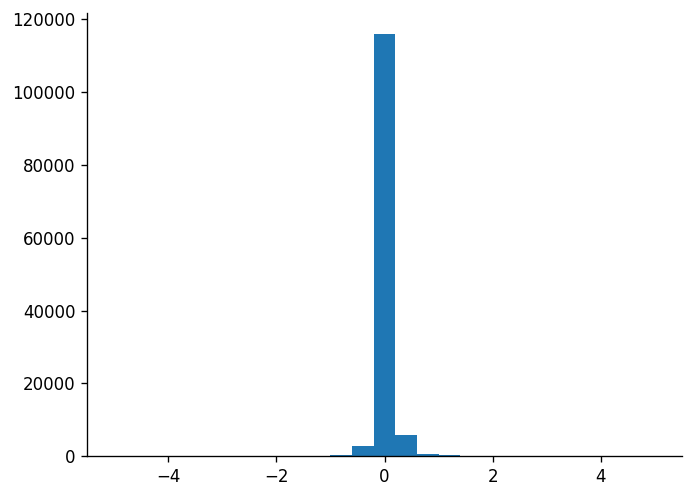

In [15]:
y_pred =lgb_model.predict(X_val)
plt.hist(y_pred * 100, range=[-5,5], bins=25)